In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import jinja2

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

In [3]:
DATASET_NAME = "monthly_ff5"

MODEL_DIR = Path("../models") / DATASET_NAME
FEATURE_DIR = Path("../data/features") / DATASET_NAME
EVALUATION_DIR = Path("../results") / DATASET_NAME

EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
final_results = pd.read_csv(
    MODEL_DIR / "final_model_results.csv"
)

test_probabilities = pd.read_csv(
    MODEL_DIR / "test_probabilities.csv"
)

xgb_thresholds = pd.read_csv(
    MODEL_DIR / "xgb_thresholds.csv",
    index_col=0
)

cnn_thresholds = pd.read_csv(
    MODEL_DIR / "cnn_thresholds.csv"
)

ensemble_settings = pd.read_csv(
    MODEL_DIR / "ensemble_settings.csv"
)

meta_test = pd.read_csv(
    FEATURE_DIR / "meta_test.csv",
    parse_dates=["Date"]
)

y_test = np.load(
    FEATURE_DIR / "y_test.npy"
)

In [5]:
print("Results shape:", final_results.shape)
print("Predictions shape:", test_probabilities.shape)
print("Metadata shape:", meta_test.shape)
print("Labels shape:", y_test.shape)

assert len(test_probabilities) == len(y_test)
assert len(meta_test) == len(y_test)
assert np.array_equal(
    test_probabilities["actual_label"].to_numpy(),
    y_test
)

display(final_results)

Results shape: (9, 7)
Predictions shape: (2800, 10)
Metadata shape: (2800, 2)
Labels shape: (2800,)


,model,threshold,accuracy,precision,recall,f1,roc_auc
0,Ensemble Combined — Test,0.47,0.208214,0.201226,0.996429,0.334833,0.493470
1,Ensemble GARCH — Test,0.22,0.215357,0.200950,0.982143,0.333637,0.498126
2,XGBoost GARCH — Test,0.19,0.216429,0.200952,0.980357,0.333536,0.498162
3,CNN Signature — Test,0.49,0.200000,0.200000,1.000000,0.333333,0.498926
4,CNN Combined — Test,0.05,0.200000,0.200000,1.000000,0.333333,0.492592
5,CNN GARCH — Test,0.41,0.199643,0.199714,0.998214,0.332837,0.486465
6,XGBoost Combined — Test,0.09,0.200714,0.199283,0.992857,0.331940,0.499207
7,Ensemble Signature — Test,0.47,0.203571,0.199424,0.989286,0.331935,0.504473
8,XGBoost Signature — Test,0.09,0.210357,0.199490,0.978571,0.331418,0.501473


In [6]:
final_results["model"] = (
    final_results["model"]
    .str.replace(" — Test", "", regex=False)
)

In [11]:
metric_columns = [
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

comparison_table = (
    final_results[metric_columns]
    .sort_values(["f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(
    comparison_table.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "roc_auc": "{:.3f}"
    })
)


,model,accuracy,precision,recall,f1,roc_auc
0,Ensemble Combined,0.208,0.201,0.996,0.335,0.493
1,Ensemble GARCH,0.215,0.201,0.982,0.334,0.498
2,XGBoost GARCH,0.216,0.201,0.980,0.334,0.498
3,CNN Signature,0.200,0.200,1.000,0.333,0.499
4,CNN Combined,0.200,0.200,1.000,0.333,0.493
5,CNN GARCH,0.200,0.200,0.998,0.333,0.486
6,XGBoost Combined,0.201,0.199,0.993,0.332,0.499
7,Ensemble Signature,0.204,0.199,0.989,0.332,0.504
8,XGBoost Signature,0.210,0.199,0.979,0.331,0.501


In [12]:
comparison_table.to_csv(
    EVALUATION_DIR / "model_comparison.csv",
    index=False
)

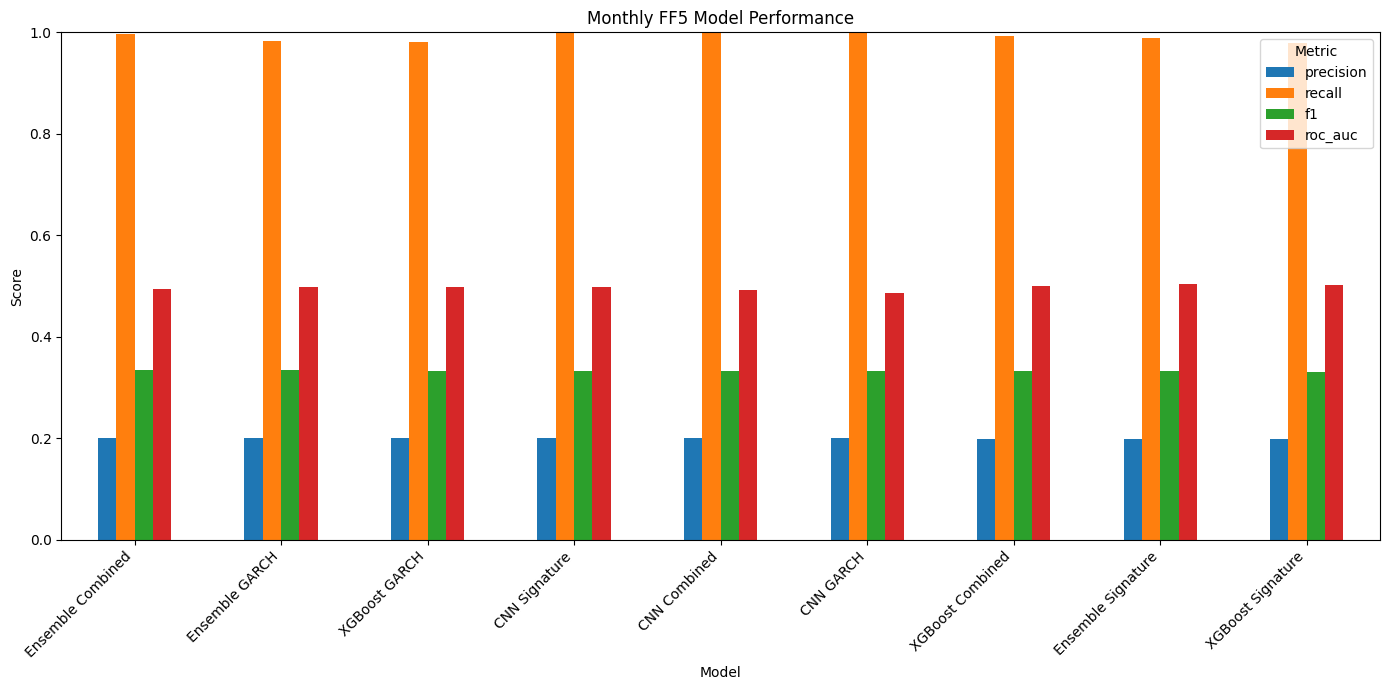

In [13]:
plot_data = comparison_table.set_index("model")[
    ["precision", "recall", "f1", "roc_auc"]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(14, 7)
)

ax.set_title("Monthly FF5 Model Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Metric")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
PROBABILITY_COLUMNS = {
    "XGBoost Signature": "xgb_signature_prob",
    "XGBoost GARCH": "xgb_garch_prob",
    "XGBoost Combined": "xgb_combined_prob",

    "CNN Signature": "cnn_signature_prob",
    "CNN GARCH": "cnn_garch_prob",
    "CNN Combined": "cnn_combined_prob",

    "Ensemble Signature": "ensemble_signature_prob",
    "Ensemble GARCH": "ensemble_garch_prob",
    "Ensemble Combined": "ensemble_combined_prob"
}

In [15]:
xgb_threshold_map = (
    xgb_thresholds["threshold"].to_dict()
)

cnn_threshold_map = dict(
    zip(
        cnn_thresholds["feature_set"],
        cnn_thresholds["threshold"]
    )
)

ensemble_threshold_map = dict(
    zip(
        ensemble_settings["feature_set"],
        ensemble_settings["threshold"]
    )
)

THRESHOLDS = {
    "XGBoost Signature": xgb_threshold_map["signature"],
    "XGBoost GARCH": xgb_threshold_map["garch"],
    "XGBoost Combined": xgb_threshold_map["combined"],

    "CNN Signature": cnn_threshold_map["signature"],
    "CNN GARCH": cnn_threshold_map["garch"],
    "CNN Combined": cnn_threshold_map["combined"],

    "Ensemble Signature": ensemble_threshold_map["signature"],
    "Ensemble GARCH": ensemble_threshold_map["garch"],
    "Ensemble Combined": ensemble_threshold_map["combined"]
}

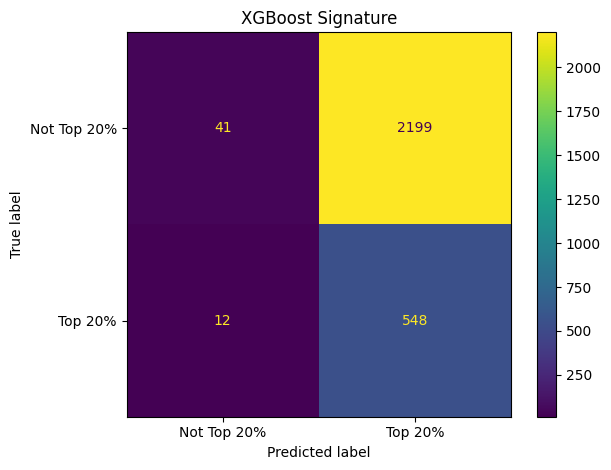

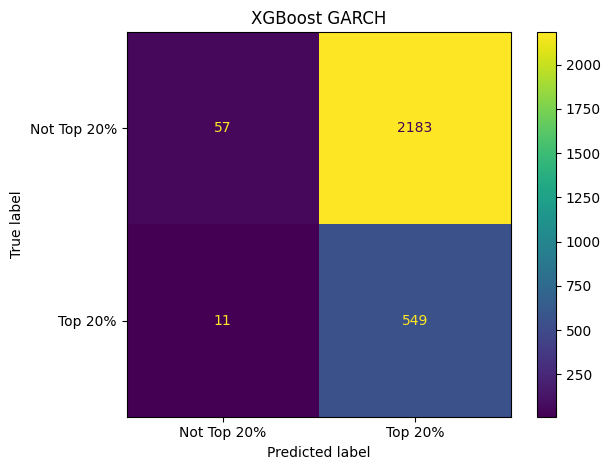

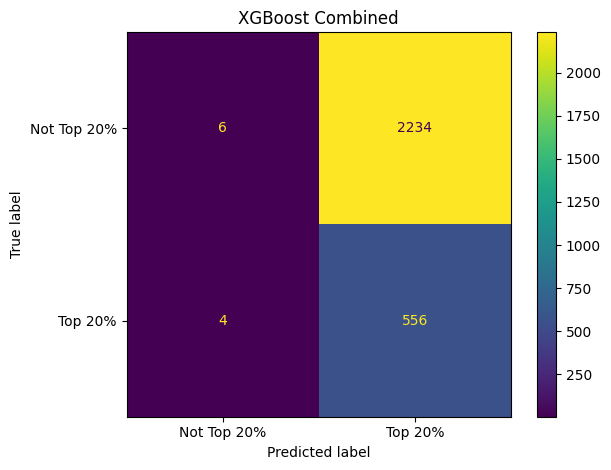

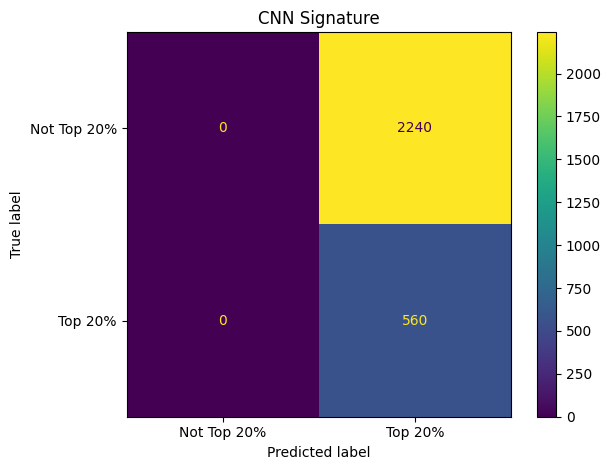

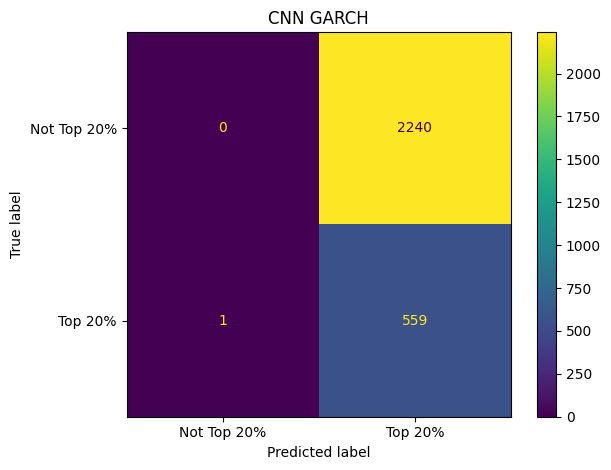

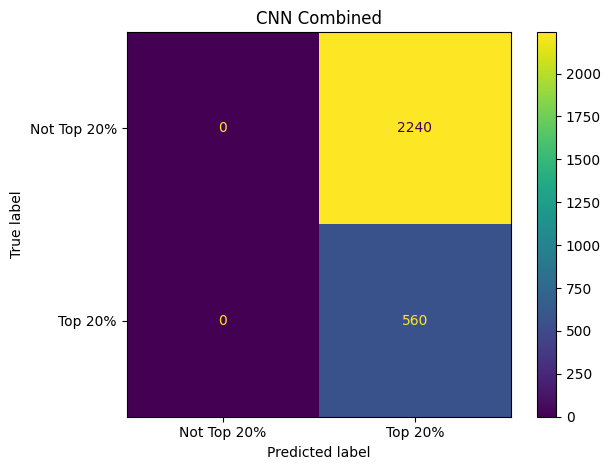

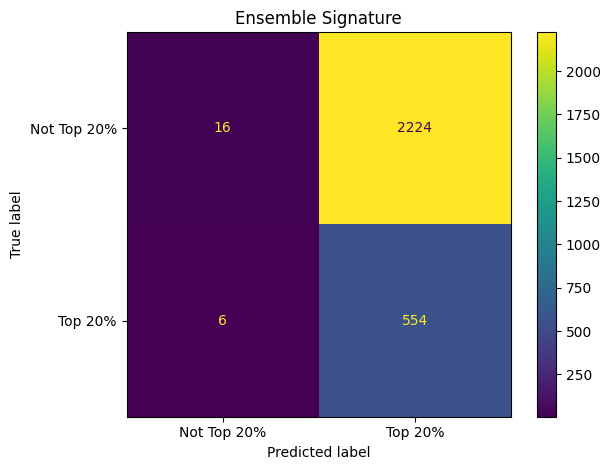

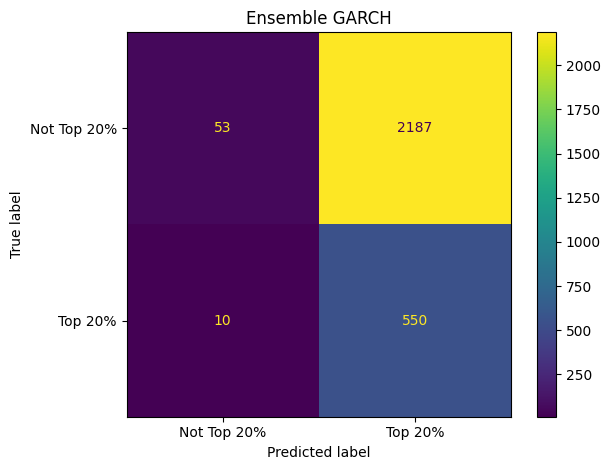

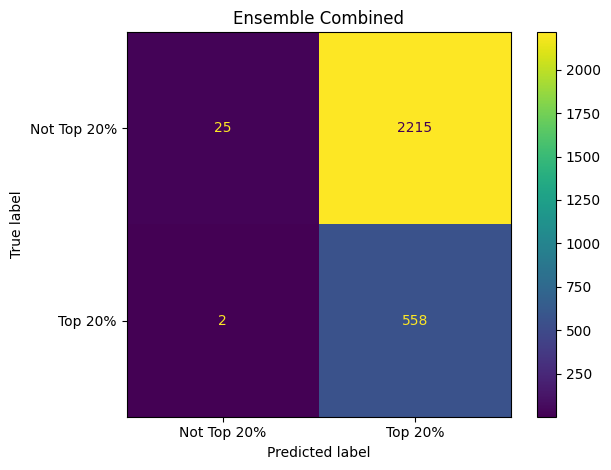

In [16]:
for model_name, probability_column in PROBABILITY_COLUMNS.items():
    probabilities = test_probabilities[
        probability_column
    ].to_numpy()

    threshold = THRESHOLDS[model_name]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    matrix = confusion_matrix(
        y_test,
        predictions
    )

    display_object = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Not Top 20%", "Top 20%"]
    )

    display_object.plot(
        values_format="d"
    )

    plt.title(model_name)
    plt.tight_layout()
    plt.show()

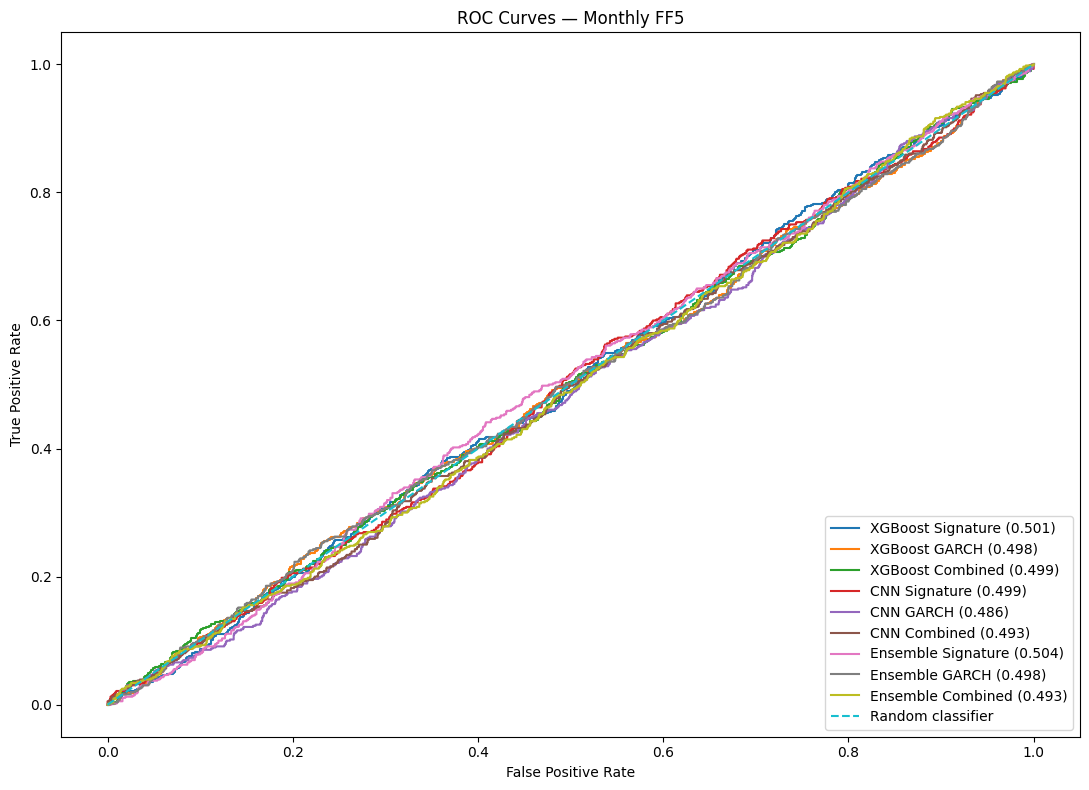

In [17]:
plt.figure(figsize=(11, 8))

for model_name, probability_column in PROBABILITY_COLUMNS.items():
    probabilities = test_probabilities[
        probability_column
    ].to_numpy()

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} ({auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("ROC Curves — Monthly FF5")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

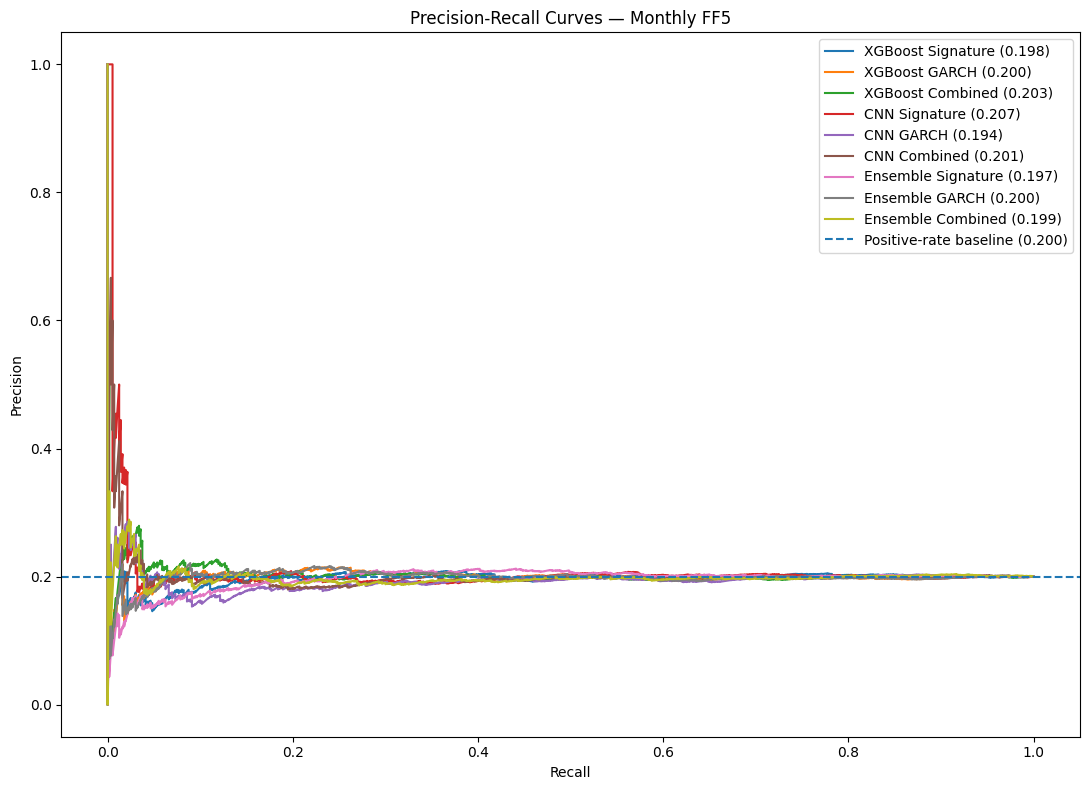

In [18]:
plt.figure(figsize=(11, 8))

for model_name, probability_column in PROBABILITY_COLUMNS.items():
    probabilities = test_probabilities[
        probability_column
    ].to_numpy()

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    average_precision = average_precision_score(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} ({average_precision:.3f})"
    )

baseline = y_test.mean()

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Positive-rate baseline ({baseline:.3f})"
)

plt.title("Precision-Recall Curves — Monthly FF5")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [19]:
cnn_histories = {
    "CNN Signature": pd.read_csv(
        MODEL_DIR / "cnn_signature_history.csv"
    ),
    "CNN GARCH": pd.read_csv(
        MODEL_DIR / "cnn_garch_history.csv"
    ),
    "CNN Combined": pd.read_csv(
        MODEL_DIR / "cnn_combined_history.csv"
    )
}

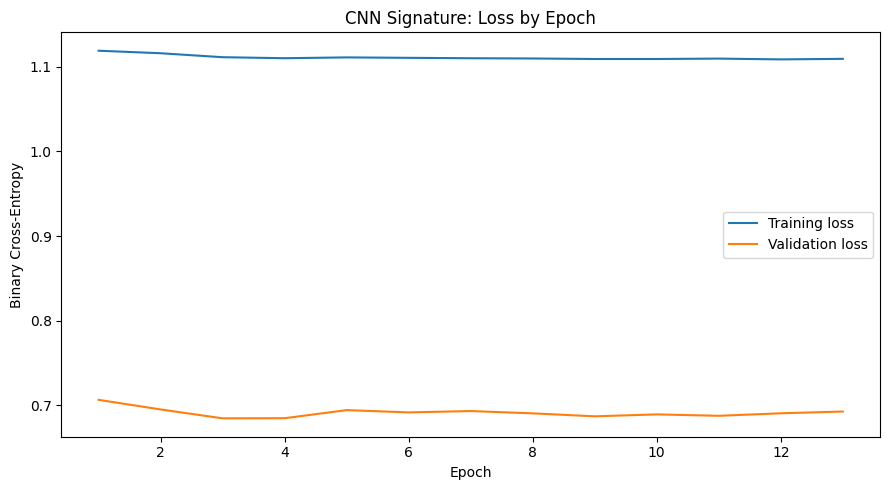

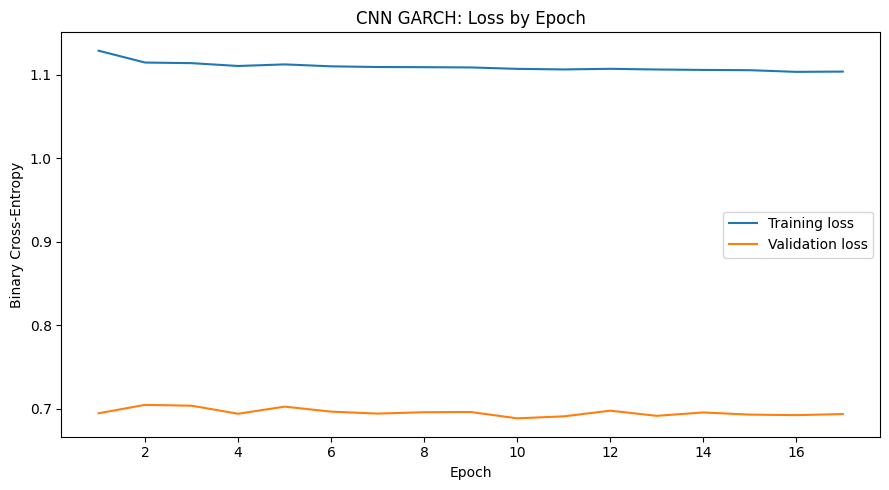

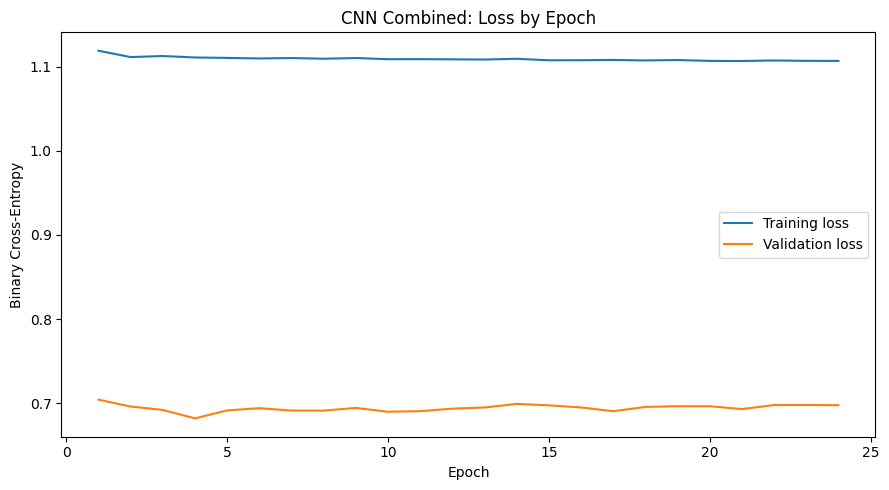

In [20]:
for model_name, history in cnn_histories.items():
    plt.figure(figsize=(9, 5))

    plt.plot(
        history.index + 1,
        history["loss"],
        label="Training loss"
    )

    plt.plot(
        history.index + 1,
        history["val_loss"],
        label="Validation loss"
    )

    plt.title(f"{model_name}: Loss by Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy")
    plt.legend()
    plt.tight_layout()
    plt.show()

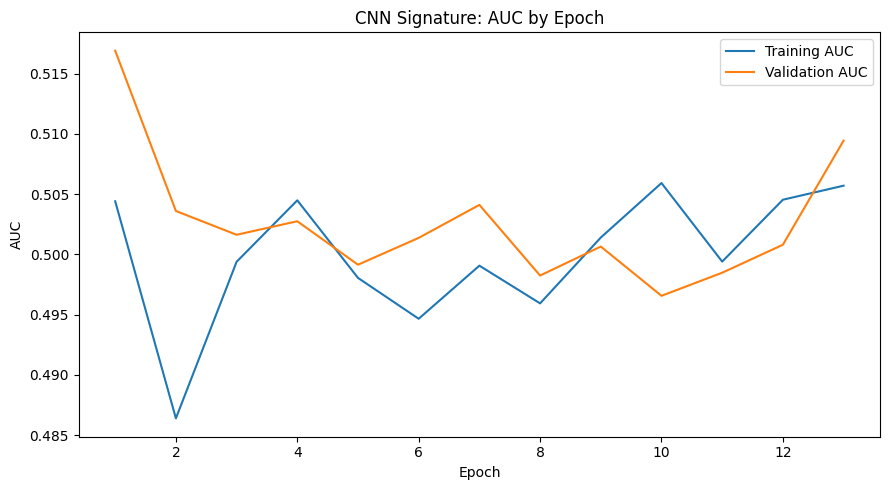

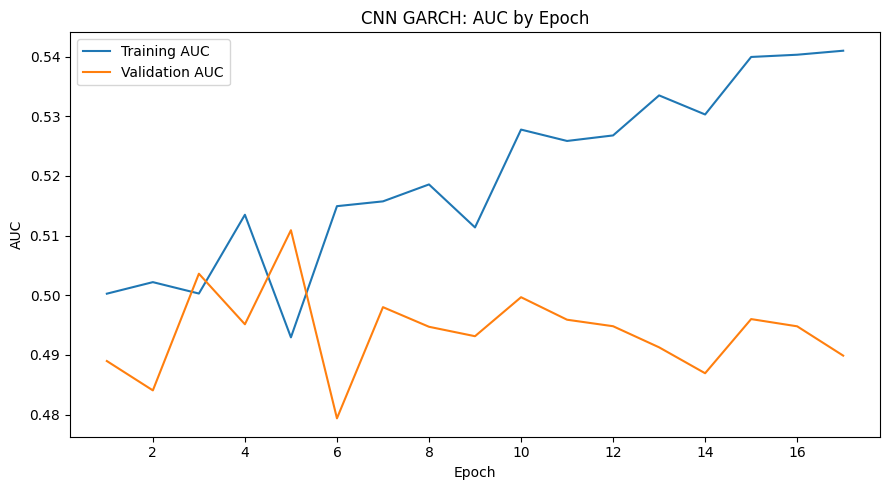

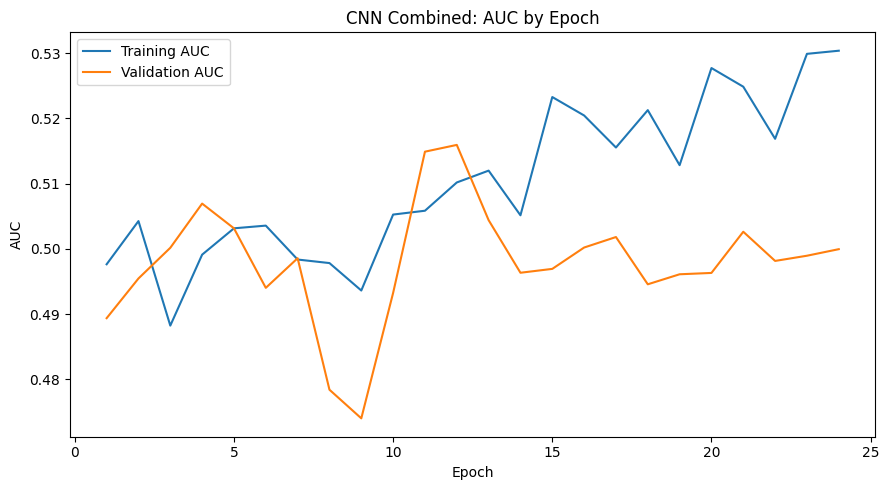

In [21]:
for model_name, history in cnn_histories.items():
    plt.figure(figsize=(9, 5))

    plt.plot(
        history.index + 1,
        history["auc"],
        label="Training AUC"
    )

    plt.plot(
        history.index + 1,
        history["val_auc"],
        label="Validation AUC"
    )

    plt.title(f"{model_name}: AUC by Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [22]:
grouped_results = comparison_table.copy()

grouped_results["architecture"] = (
    grouped_results["model"]
    .str.extract(r"^(XGBoost|CNN|Ensemble)")
)

grouped_results["feature_type"] = (
    grouped_results["model"]
    .str.extract(r"(Signature|GARCH|Combined)$")
)

architecture_summary = (
    grouped_results
    .groupby("architecture")[
        ["precision", "recall", "f1", "roc_auc"]
    ]
    .mean()
    .sort_values("f1", ascending=False)
)

feature_summary = (
    grouped_results
    .groupby("feature_type")[
        ["precision", "recall", "f1", "roc_auc"]
    ]
    .mean()
    .sort_values("f1", ascending=False)
)

print("Average performance by architecture")
display(architecture_summary)

print("Average performance by feature type")
display(feature_summary)

Average performance by architecture


,precision,recall,f1,roc_auc
architecture,,,,
Ensemble,0.200533,0.989286,0.333468,0.498690
CNN,0.199905,0.999405,0.333168,0.492661
XGBoost,0.199908,0.983929,0.332298,0.499614


Average performance by feature type


,precision,recall,f1,roc_auc
feature_type,,,,
Combined,0.200170,0.996429,0.333369,0.495090
GARCH,0.200539,0.986905,0.333337,0.494251
Signature,0.199638,0.989286,0.332229,0.501624


In [23]:
prediction_detail = meta_test.copy()

prediction_detail["actual_label"] = y_test

for model_name, probability_column in PROBABILITY_COLUMNS.items():
    prediction_detail[probability_column] = (
        test_probabilities[probability_column].to_numpy()
    )

display(prediction_detail.head())

,Date,Portfolio,actual_label,xgb_signature_prob,xgb_garch_prob,xgb_combined_prob,cnn_signature_prob,cnn_garch_prob,cnn_combined_prob,ensemble_signature_prob,ensemble_garch_prob,ensemble_combined_prob
0,2016-12-01,SMALL LoBM,0,0.209247,0.441335,0.252384,0.510887,0.514948,0.495349,0.480723,0.448696,0.483201
1,2016-12-01,ME1 BM2,0,0.285038,0.429866,0.395461,0.510988,0.515748,0.496064,0.488393,0.438454,0.491034
2,2016-12-01,ME1 BM3,0,0.260749,0.681254,0.331918,0.510239,0.553818,0.498812,0.485290,0.668511,0.490467
3,2016-12-01,ME1 BM4,0,0.459099,0.415666,0.403396,0.507868,0.544270,0.498797,0.502992,0.428526,0.494026
4,2016-12-01,SMALL HiBM,0,0.277654,0.650161,0.309840,0.508733,0.542793,0.499193,0.485625,0.639424,0.489726


In [24]:
def evaluate_top_k_selection(
    prediction_data,
    probability_column,
    k=5
):
    """
    For each date, select the k portfolios with the highest predicted
    probabilities and measure how many are truly in the top-return class.
    """

    records = []

    for date, group in prediction_data.groupby("Date"):
        selected = group.nlargest(
            k,
            probability_column
        )

        true_positives = selected["actual_label"].sum()

        records.append({
            "Date": date,
            "selected_count": len(selected),
            "correct_selections": int(true_positives),
            "precision_at_k": true_positives / len(selected)
        })

    return pd.DataFrame(records)

In [25]:
top_k_results = []

top_k_time_series = {}

for model_name, probability_column in PROBABILITY_COLUMNS.items():
    result = evaluate_top_k_selection(
        prediction_detail,
        probability_column,
        k=5
    )

    top_k_time_series[model_name] = result

    top_k_results.append({
        "model": model_name,
        "mean_precision_at_5": result[
            "precision_at_k"
        ].mean(),
        "median_precision_at_5": result[
            "precision_at_k"
        ].median(),
        "perfect_selection_rate": (
            result["correct_selections"] == 5
        ).mean()
    })

top_k_summary = (
    pd.DataFrame(top_k_results)
    .sort_values(
        "mean_precision_at_5",
        ascending=False
    )
    .reset_index(drop=True)
)

display(top_k_summary)

,model,mean_precision_at_5,median_precision_at_5,perfect_selection_rate
0,CNN Combined,0.232143,0.2,0.0
1,Ensemble Combined,0.226786,0.2,0.0
2,CNN Signature,0.223214,0.2,0.0
3,XGBoost Signature,0.216071,0.2,0.0
4,XGBoost Combined,0.216071,0.2,0.0
5,CNN GARCH,0.210714,0.2,0.0
6,Ensemble Signature,0.201786,0.2,0.0
7,XGBoost GARCH,0.196429,0.2,0.0
8,Ensemble GARCH,0.192857,0.2,0.0


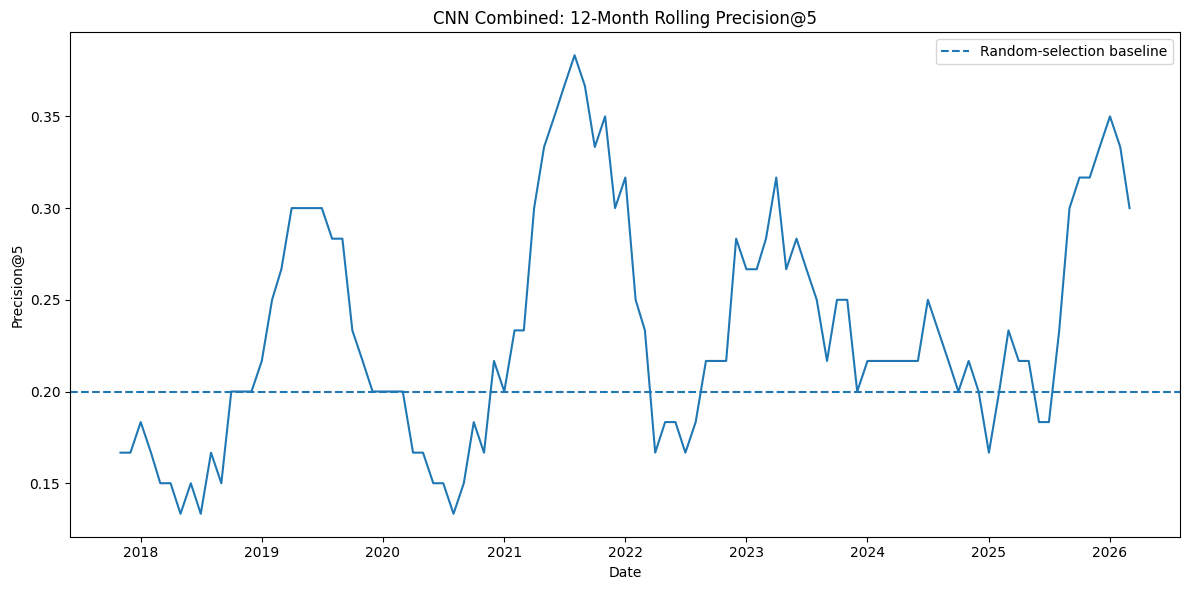

In [26]:
best_model_name = top_k_summary.loc[
    0,
    "model"
]

best_top_k = top_k_time_series[
    best_model_name
].copy()

best_top_k["rolling_precision_at_5"] = (
    best_top_k["precision_at_k"]
    .rolling(12)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    best_top_k["Date"],
    best_top_k["rolling_precision_at_5"]
)

plt.axhline(
    0.20,
    linestyle="--",
    label="Random-selection baseline"
)

plt.title(
    f"{best_model_name}: 12-Month Rolling Precision@5"
)
plt.xlabel("Date")
plt.ylabel("Precision@5")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
architecture_summary.to_csv(
    EVALUATION_DIR / "architecture_summary.csv"
)

feature_summary.to_csv(
    EVALUATION_DIR / "feature_summary.csv"
)

top_k_summary.to_csv(
    EVALUATION_DIR / "top_k_summary.csv",
    index=False
)

prediction_detail.to_csv(
    EVALUATION_DIR / "prediction_detail.csv",
    index=False
)

print("Evaluation outputs saved to:")
print(EVALUATION_DIR.resolve())

Evaluation outputs saved to:
C:\Users\kyler\Documents\VS_Code\Finance Code\ML using FAMA and FRENCH\results\monthly_ff5
